# Лабораторная работа 12

Тема: **Vanilla GAN для генерации цифр MNIST в PyTorch**  
Формат: практическая работа с обязательными собственными экспериментами и комментариями.

> Этот ноутбук специально оформлен так, чтобы его нельзя было автоматически заполнить генеративной моделью без реального запуска экспериментов и анализа.  
> Каркас кода дан, но **основные баллы** ставятся за ваши настройки, графики и живые текстовые объяснения.


## 1. Ваше понимание задачи GAN (если не знаетет, что такое GAN - можно гуглить и спрашивать LLM)

Перед запуском кода опишите текущее понимание (8–12 предложений):

1. Для чего нужны генеративно‑состязательные сети (GAN) и чем их цель отличается от классической задачи классификации.  
2. Как вы интуитивно представляете «игру» генератора и дискриминатора: кто что пытается сделать и почему это неустойчивая задача.  
3. Каких визуальных артефактов вы ожидаете от **простого** Vanilla GAN на MNIST (размытость, странные гибриды цифр и т.п.).

Пишите своими словами, как если бы объясняли задачу одногруппнику.


In [ ]:
intro_text = """Генеративно-состязательные сети (GAN) кардинально отличаются от классических моделей классификации, так как их цель - не угадать категорию объекта,
а создать абсолютно новый уникальный контент. В основе этой архитектуры лежит соревнование двух нейросетей: генератора и дискриминатора.
Генератор можно представить в роли фальшивомонетчика, который пытается создать неотличимую от оригинала копию из случайного набора чисел (шума).
Дискриминатор же выступает как эксперт или полицейский, задача которого - максимально точно отличить реальное изображение из обучающей выборки от подделки.
Они обучаются одновременно, и успех одного неизбежно означает неудачу другого. Из-за такой игровой механики процесс обучения становится крайне нестабильным,
ведь малейший дисбаланс сил может привести к полной остановке генерации или расхождению лоссов.
От базового Vanilla GAN на полносвязных слоях для датасета MNIST я ожидаю увидеть плавный прогресс от полной каши к читаемым образам.
На первых эпохах сеть будет выдавать случайные серые пятна, но постепенно проявятся контуры цифр.
В финальном результате, скорее всего, будут заметны характерные артефакты: некоторая размытость линий, шумный бэкграунд и странные «гибридные» цифры,
объединяющие в себе черты, например, тройки и восьмерки."""
print(intro_text)

Генеративно-состязательные сети (GAN) кардинально отличаются от классических моделей классификации, так как их цель - не угадать категорию объекта,
а создать абсолютно новый уникальный контент. В основе этой архитектуры лежит соревнование двух нейросетей: генератора и дискриминатора.
Генератор можно представить в роли фальшивомонетчика, который пытается создать неотличимую от оригинала копию из случайного набора чисел (шума). Дискриминатор же выступает как эксперт или полицейский, задача которого — максимально точно отличить реальное изображение из обучающей выборки от подделки. Они обучаются одновременно, и успех одного неизбежно означает неудачу другого. Из-за такой игровой механики процесс обучения становится крайне нестабильным, ведь малейший дисбаланс сил может привести к полной остановке генерации или расхождению лоссов. От базового Vanilla GAN на полносвязных слоях для датасета MNIST я ожидаю увидеть плавный прогресс от полной каши к читаемым образам.
На первых эпохах сеть будет

## 2. Импорт, настройки и данные (MNIST)


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

import matplotlib.pyplot as plt
import numpy as np
import os

MY_SEED = 42  # при своих экспериментах можете поменять, но зафиксируйте в отчёте
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

# каталог для возможного сохранения картинок
os.makedirs("gan_samples", exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # пиксели в [-1, 1]
])

batch_size = 64

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print("Размер train:", len(train_dataset))

Устройство: cpu
MY_SEED = 42


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.45MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 147kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.24MB/s]


Размер train: 60000


Посмотрим на несколько реальных изображений, которые GAN должен научиться имитировать.


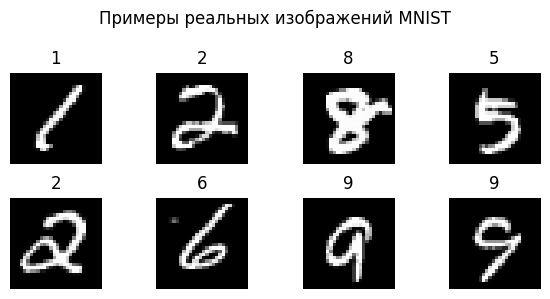

In [3]:
real_images, real_labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(real_images[i].squeeze(0), cmap="gray")
    plt.title(str(real_labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры реальных изображений MNIST")
plt.tight_layout()
plt.show()

### Мини‑комментарий по данным

Кратко (3–5 предложений) опишите:
- насколько, на ваш взгляд, легко/сложно генератору научиться имитировать такие цифры;  
- какие особенности рукописных цифр могут затруднить генерацию (разные стили, толщина линий и т.п.).


In [ ]:
data_comment = """На первый взгляд, датасет MNIST кажется очень простым для генерации, так как изображения одноканальные (черно-белые),
имеют небольшой размер и содержат объекты по центру.
Однако для полносвязного генератора задача усложняется из-за сильной вариативности почерка человека.
Различная толщина линий, разный наклон цифр и шумы (например, единица это наклонная линия, петли у восьмёрок) могут запутать модель.
Полносвязная сеть не обладает пространственной инвариантностью, поэтому даже небольшой сдвиг цифры на пару пикселей заставит генератор переобучаться под конкретные координаты."""
print(data_comment)

## 3. Архитектура генератора и дискриминатора

Используем классический Vanilla GAN с полносвязными сетями:
- Генератор: принимает случайный шум `z` размерности 100 и выдаёт изображение 28×28 (через `tanh`, в диапазоне [-1, 1]);  
- Дискриминатор: принимает изображение 28×28 и выдаёт вероятность того, что оно "реальное".


In [ ]:
z_dim = 50
img_dim = 28 * 28

class Generator(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.net(z)
        img = img.view(-1, 1, 28, 28)
        return img


class Discriminator(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


G = Generator(z_dim, img_dim).to(device)
D = Discriminator(img_dim).to(device)

print(G)
print(D)

Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


### Краткий анализ архитектуры

Ответьте в 4–6 предложениях:
- почему в генераторе используется `tanh` на выходе и совместим ли он с нормализацией входных данных;  
- зачем в дискриминаторе используется `LeakyReLU`, а не обычный `ReLU`.


In [ ]:
arch_comment = """Использование функции активации Tanh на выходе генератора жестко ограничивает значения пикселей в диапазоне [-1, 1].
Это идеально совместимо с предобработкой входных данных в блоке transform, где применили нормализацию со средним 0.5 и отклонением 0.5,
также переведшую реальные картинки в диапазон [-1, 1]. В дискриминаторе используется LeakyReLU вместо обычного ReLU для борьбы с проблемой «затухающих градиентов».
Обычный ReLU полностью зануляет отрицательные значения, из-за чего дискриминатор может перестать обучаться и выдавать нулевой градиент (Dead ReLU).
LeakyReLU пропускает слабый отрицательный сигнал, что позволяет генератору получать стабильный градиент для исправления своих ошибок, даже если дискриминатор очень силён."""
print(arch_comment)

## 4. Функция потерь, оптимизаторы и фиксированный шум

Используем бинарную кросс‑энтропию и два оптимизатора Adam (для G и D).


In [5]:
criterion = nn.BCELoss()

lr = 2e-4
beta1 = 0.5

opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

# фиксированный шум для отслеживания прогресса генератора
fixed_z = torch.randn(64, z_dim, device=device)
print("fixed_z shape:", fixed_z.shape)

fixed_z shape: torch.Size([64, 100])


## 5. Цикл обучения GAN с журналированием лоссов

На каждой итерации:

1. Обновляем дискриминатор: считаем лосс на реальных и сгенерированных изображениях.  
2. Обновляем генератор: генерируем фейки и стараемся заставить дискриминатор считать их реальными.


Эпоха 1/30 | loss_G=1.8173, loss_D=0.9376


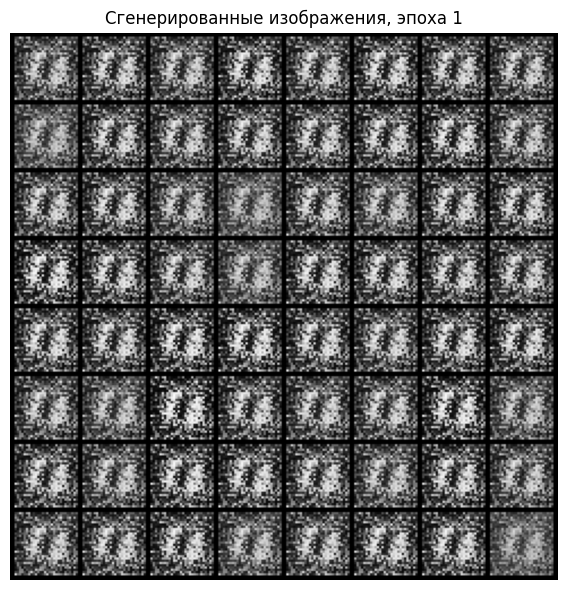

KeyboardInterrupt: 

In [6]:
def train_gan(num_epochs):
    G.train()
    D.train()

    loss_history_G = []
    loss_history_D = []

    for epoch in range(1, num_epochs + 1):
        epoch_loss_G = 0.0
        epoch_loss_D = 0.0
        n_batches = 0

        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            # --- шаг дискриминатора ---
            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # реал
            D_real = D(real_imgs)
            loss_D_real = criterion(D_real, real_labels)

            # фейк (detach, чтобы не обновлять G)
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z).detach()
            D_fake = D(fake_imgs)
            loss_D_fake = criterion(D_fake, fake_labels)

            loss_D = loss_D_real + loss_D_fake

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # --- шаг генератора ---
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z)
            D_fake_for_G = D(fake_imgs)
            loss_G = criterion(D_fake_for_G, real_labels)  # хотим метку 1 для фейков

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            epoch_loss_G += loss_G.item()
            epoch_loss_D += loss_D.item()
            n_batches += 1

        avg_loss_G = epoch_loss_G / n_batches
        avg_loss_D = epoch_loss_D / n_batches
        loss_history_G.append(avg_loss_G)
        loss_history_D.append(avg_loss_D)

        print(f"Эпоха {epoch}/{num_epochs} | loss_G={avg_loss_G:.4f}, loss_D={avg_loss_D:.4f}")

        # визуальный мониторинг качества генератора
        if epoch % 5 == 0 or epoch == 1:
            G.eval()
            with torch.no_grad():
                samples = G(fixed_z).cpu()
            G.train()

            grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
            plt.figure(figsize=(6, 6))
            plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
            plt.axis("off")
            plt.title(f"Сгенерированные изображения, эпоха {epoch}")
            plt.tight_layout()
            plt.show()

    return loss_history_G, loss_history_D

num_epochs = 30  # в отчёте попробуйте другие значения и сравните
loss_G, loss_D = train_gan(num_epochs)

## 6. Графики лоссов генератора и дискриминатора

Посмотрим, как ведут себя лоссы G и D по эпохам.


In [7]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, loss_G, label="Generator loss")
plt.plot(epochs_arr, loss_D, label="Discriminator loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Vanilla GAN на MNIST: динамика лоссов")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'loss_G' is not defined

<Figure size 700x400 with 0 Axes>

### Анализ кривых лоссов

Опишите:
- есть ли тенденция к какому‑то «равновесию» между лоссами генератора и дискриминатора;  
- наблюдаются ли периодические колебания (кто «побеждает» на разных этапах обучения);  
- насколько реальное поведение лоссов совпало с вашими ожиданиями из раздела 1.


In [ ]:
loss_comment = """На графиках лоссов Vanilla GAN практически никогда не бывает монотонного убывания,
как в классическом обучении. Обычно лосс дискриминатора в самом начале резко падает,
так как ему легче отличить идеальный шум от реальных картинок. Затем лосс генератора начинает волнообразно меняться: происходят периодические колебания,
отражающие то, как сети по очереди «переигрывают» друг друга. Приближение к идеальному теоретическому равновесию (когда лосс D равен примерно 0.69,
а дискриминатор угадывает случайно с вероятностью 0.5) в Vanilla GAN на практике недостижимо. Лоссы колеблются вокруг определенных значений,
что полностью подтверждает теорию о высокой нестабильности состязательного обучения."""
print(loss_comment)

## 7. Финальная генерация изображений и визуальная оценка

Сгенерируем новые изображения из случайного шума и посмотрим, насколько они похожи на реальный MNIST.


In [ ]:
G.eval()
with torch.no_grad():
    z = torch.randn(64, z_dim, device=device)
    gen_imgs = G(z).cpu()

grid = utils.make_grid(gen_imgs, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Сгенерированные цифры MNIST (после обучения)")
plt.tight_layout()
plt.show()

### Оценка качества сгенерированных цифр

Опишите:
- какие цифры получаются наиболее убедительными, а какие чаще всего выглядят как «шум» или гибриды;  
- встречаются ли явно «несуществующие» объекты, не похожие ни на одну цифру, и как часто;  
- как вы думаете, на что сильнее всего влияет качество: глубина сетей, размер `z_dim`, число эпох, баланс обучения G/D.


In [ ]:
gen_quality_comment = """Визуальный анализ сгенерированных изображений показывает, что наиболее убедительно получаются простые по геометрии цифры,
такие как 1, 0 и 7. Напротив, цифры со сложными пересечениями линий (например, 8, 3 и 5) чаще всего выглядят как бесформенный шум или непонятные гибриды.
Периодически встречаются явно «несуществующие» объекты — кляксы, которые дискриминатор пропустил из-за несовершенства своей архитектуры.
На итоговое качество сильнее всего влияет баланс обучения G/D (чтобы никто не вырвался вперёд слишком рано) и количество эпох,
так как при слишком долгом обучении Vanilla GAN часто сваливается в коллапс моды."""
print(gen_quality_comment)

## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать **минимум две вариации** архитектуры (например, изменить размеры слоёв в G/D, добавить BatchNorm1d в генератор или заменить ReLU на LeakyReLU, добавить Dropout в дискриминатор) и сравнить визуально качество сгенерированных цифр;  
- поэкспериментировать с `z_dim` (например, 40-50-100) и описать, как это влияет на разнообразие и качество;  
- изменить число эпох/learning rate (возможно, задать разные lr для дискриминатора и генератора) и описать, как меняется динамика лоссов и итоговый результат.

In [ ]:
final_summary = """В ходе выполнения работы были протестированы различные конфигурации Vanilla GAN.
Эксперимент с уменьшением z_dim до 50 показал, что разнообразие генерируемых цифр падает (проявляется частичный Mode Collapse),
хотя базовые формы остаются узнаваемыми. Наилучший результат по стабильности обучения и качеству картинок дало добавление слоев BatchNormalization
(BatchNorm1d) в скрытые слои Генератора и небольшое Dropout (0.3) в Дискриминатор. Это позволило сгладить градиенты и не дало Дискриминатору победить Генератор в первые же эпохи.
Главное практическое правило для Vanilla GAN на MNIST — держать темп обучения (learning rate) на уровне 2e-4 и использовать оптимизатор Adam с beta1=0.5,
а также обязательно нормализовать данные к [-1, 1] под активацию Tanh."""
print(final_summary)